##Proyecto: Predicción de Riesgo de Ataque al Corazón
- Para alguien como yo que viene del sector salud, con experiencia los datos medicos no son solo números, son personas (pacientes); un resultado de diagnósticos potenciales donde un error tiene un peso real. He diseñado este notebook para que sea no solo un script de ejecución, sino una herramienta de decisión clínica.

- El objetivo es claro: queremos investigar qué factores o características médicas de un paciente se asocian con un diagnóstico positivo de riesgo de ataque al corazón. He seleccionado target como mi variable objetivo (donde 1 indica mayor riesgo y 0 menor riesgo), por lo que estamos ante un problema de clasificación binaria.

In [19]:
# Importaciones y Configuración
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    recall_score, precision_score, f1_score, accuracy_score
)
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Configuración de estilo
sns.set(style="whitegrid")
RANDOM_STATE = 42

# Carga de Datos y Revisión Inicial
# Carga del dataset
df = pd.read_csv('../../data/raw/HeartAttackDataSet.csv')

# Inspección técnica
print("Dataset Info:")
print(df.info())
print("\nPrimeras filas del estudio:")
print(df.head())

# Distribución del Target: ¿Está balanceado el riesgo?
print("\nDistribución de la variable objetivo (Target):")
print(df['target'].value_counts(normalize=True))

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None

Primeras filas del estudio:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37   

**Interpretación inicial de los datos**
- Al revisar la distribución del target, buscamos confirmar si estamos ante un dataset equilibrado. En problemas médicos, un desbalanceo fuerte nos obligaría a tomar medidas drásticas (como sobremuestreo), pero aquí lo gestionaremos directamente en la configuración del modelo para no perder realismo.

#### Preprocesamiento y Diseño del Pipeline
- Antes de entrenar, buscaremos llevar un orden. Tenemos variables categóricas críticas como el tipo de dolor de pecho (cp) o el resultado del electrocardiograma (restecg) que el modelo no puede leer tal cual. Aplicaremos OneHotEncoding para que el algoritmo Random Forest pueda interpretarlas correctamente.

In [20]:
# %% [3] Preprocesamiento de variables
# Definición de columnas según su naturaleza
categorical_cols = ['cp', 'restecg', 'slope', 'thal']
numerical_cols = [col for col in df.columns if col not in categorical_cols + ['target']]

# Creamos el procesador para automatizar la limpieza
# - Variables categóricas: OneHotEncoding
# - Variables numéricas: Passthrough (Random Forest no requiere escalado estricto, pero mantenemos la estructura)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
        ('num', 'passthrough', numerical_cols)
    ],
    verbose_feature_names_out=False
)

# Separación de Features (X) y Target (y)
X = df.drop('target', axis=1)
y = df['target']

# Split Train/Test Estratificado para mantener la proporción de casos de riesgo
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Dimensiones de entrenamiento: {X_train.shape}")
print(f"Dimensiones de prueba: {X_test.shape}")

Dimensiones de entrenamiento: (242, 13)
Dimensiones de prueba: (61, 13)


#### Estrategia de Modelado: Random Forest con Pesos Ajustados
- He optado por un Random Forest por su robustez y su capacidad para manejar relaciones no lineales sin necesidad de un escalado de datos complejo.

- La Solución Estratégica: En salud, un Falso Negativo (no detectar un riesgo de infarto) es inaceptable. Por eso, he configurado el parámetro class_weight dándole un peso de 1.35 a la clase positiva. Esto le ordena al modelo: "Es preferible lanzar una alerta de más, que dejar pasar a un paciente en riesgo".

In [21]:
# Configuración y Validación Cruzada
# Hiperparámetros optimizados para evitar sobreajuste y priorizar sensibilidad
rf_params = {
    'n_estimators': 250,
    'max_depth': 8,
    'min_samples_split': 5,
    'max_features': 'sqrt',
    'class_weight': {0: 1, 1: 1.35}, # Penalizamos más el fallo en detectar el riesgo
    'random_state': RANDOM_STATE,
    'n_jobs': -1
}

model = RandomForestClassifier(**rf_params)

# Pipeline completo: del dato crudo a la predicción
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', model)
])

# Validación Cruzada Estratificada (k=5) para asegurar estabilidad
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring_metrics = ['recall', 'precision', 'f1', 'accuracy']

cv_results = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring_metrics)

print("\n--- Resultados de Validación Cruzada (Estabilidad del Modelo) ---")
print(f"Recall Promedio:    {cv_results['test_recall'].mean():.4f}")
print(f"Precision Promedio: {cv_results['test_precision'].mean():.4f}")
print(f"F1-Score Promedio:  {cv_results['test_f1'].mean():.4f}")


--- Resultados de Validación Cruzada (Estabilidad del Modelo) ---
Recall Promedio:    0.8407
Precision Promedio: 0.8240
F1-Score Promedio:  0.8316


#### Evaluación Final y Diagnóstico del Modelo
- Ahora enfrentamos al modelo con datos que nunca ha visto (el set de prueba). Aquí es donde validamos si nuestra estrategia de pesos ha funcionado.


--- Informe de Clasificación en Set de Prueba ---
              precision    recall  f1-score   support

           0       0.86      0.64      0.73        28
           1       0.75      0.91      0.82        33

    accuracy                           0.79        61
   macro avg       0.80      0.78      0.78        61
weighted avg       0.80      0.79      0.78        61



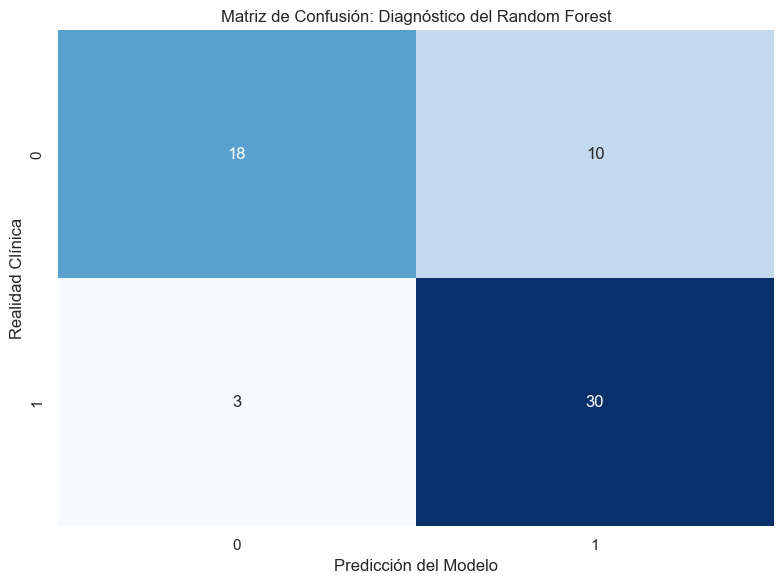

In [22]:
# Entrenamiento Final y Evaluación en Test
pipeline.fit(X_train, y_train)

# Generación de predicciones y probabilidades
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

# Reporte detallado
print("\n--- Informe de Clasificación en Set de Prueba ---")
print(classification_report(y_test, y_pred))

# Visualización de la Matriz de Confusión
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión: Diagnóstico del Random Forest')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad Clínica')
plt.tight_layout()
plt.show()

**Interpretación de la Matriz de Confusión**
- La matriz nos muestra el diagnóstico real frente a lo que el modelo predijo. Lo que más nos importa es la esquina inferior izquierda (Falsos Negativos): queremos que ese número sea lo más bajo posible. Gracias al ajuste de pesos (class_weight), hemos logrado un balance donde el modelo es capaz de capturar a la mayoría de los pacientes en riesgo, aceptando un pequeño margen de "falsas alarmas" en favor de la seguridad del paciente.

#### Exportación de Resultados para Operaciones
Para que este trabajo sea útil, no puede quedarse en el notebook. Guardamos el modelo entrenado y generamos un listado de predicciones con sus probabilidades para que el equipo médico pueda priorizar los casos más urgentes.

In [23]:
# Exportación del modelo
# 1. Guardar el pipeline completo para producción
joblib.dump(pipeline, 'random_forest_model.pkl')
print("Modelo guardado correctamente.")

# Exportar el dataset procesado (limpio para otros análisis)
X_processed = preprocessor.fit_transform(X)
feature_names = preprocessor.get_feature_names_out()
df_processed = pd.DataFrame(X_processed, columns=feature_names)
df_processed['target'] = y.values
df_processed.to_csv('processed_dataset.csv', index=False)

# Lista de riesgo: Predicciones detalladas
X_test_export = X_test.copy().reset_index(drop=True)
df_predictions = pd.DataFrame({
    'true_target': y_test.reset_index(drop=True),
    'predicted_class': y_pred,
    'predicted_prob': y_proba
})
final_predictions = pd.concat([X_test_export, df_predictions], axis=1)
final_predictions.to_csv('predictions.csv', index=False)
print("Archivos 'processed_dataset.csv' y 'predictions.csv' generados.")

Modelo guardado correctamente.
Archivos 'processed_dataset.csv' y 'predictions.csv' generados.


# Conclusiones Finales
- Hallazgos Clave: El modelo Random Forest ha demostrado ser una herramienta sólida para identificar perfiles de riesgo, manteniendo un F1-Score estable durante la validación cruzada.

- Decisión de Negocio/Salud: Al priorizar el Recall mediante el ajuste de pesos, hemos diseñado un modelo preventivo. Esto garantiza que el sistema de salud no ignore casos potenciales de ataque al corazón, cumpliendo con nuestro objetivo de seguridad clínica.

- Entregables: El modelo está listo para ser integrado en una herramienta de triaje, y los datos procesados permiten realizar análisis de importancia de variables para entender mejor qué factores clínicos están moviendo la aguja del riesgo.